In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialise ANN
import NeuralNet
import layer
import dataset

data = dataset.load()
data.head()

,Diagnosis,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, Y_train, X_test, Y_test = dataset.train_test(data)

In [4]:
# initializing variable hyperparamters
epochs = [1, 50, 100, 150, 200]
lr = [0.01, 0.05, 0.1, 0.5, 1.0]
hidden_layers = [1, 2, 3, 4, 5]
hidden_neurons = [1, 2, 3, 4, 5]

# epoch change
def epoch_test(epochs, int, act = 3):
    loss = []
    accuracy = []
    time = []

    for i in epochs:
        ann = NeuralNet.ANN(X_train, Y_train, epoch = i, loss = int)
        activations = [act, act] 
        ann.setLayers(activations, [2, 2]) 
        l, a, t = ann.train()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

# activation function change
def activation_test(act):
    loss = []
    accuracy = []
    time = []
    ann = NeuralNet.ANN(X_train, Y_train)
    activations = [act, act] 
    ann.setLayers(activations, [2, 2]) 
    l, a, t = ann.train()

    return l, a, t

# learning rate change (with and without scheduler)
def lr_test(lr, sch):
    loss = []
    accuracy = []
    time = []

    for i in lr:
        ann = NeuralNet.ANN(X_train, Y_train, learn_rate = i, lrschedule = sch)
        activations = [2, 2] 
        ann.setLayers(activations, [2, 2])  
        l, a, t = ann.train()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

# hidden layers change
def hl_test(hidden_layers):
    loss = []
    accuracy = []
    time = []

    for i in hidden_layers:
        ann = NeuralNet.ANN(X_train, Y_train)
        activations = []
        nodes = []
        for j in range(i+1):
            activations.append(2)
            nodes.append(1)
        ann.setLayers(activations, nodes) 
        l, a, t = ann.train()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

# hidden nodes change
def hn_test(hidden_neurons, layers):
    loss = []
    accuracy = []
    time = []

    for i in hidden_neurons:
        ann = NeuralNet.ANN(X_train, Y_train)
        activations = []
        nodes = []
        for j in range(layers):
            activations.append(2)
            nodes.append(i)
        activations.append(2)
        nodes.append(2)
        ann.setLayers(activations, nodes)
        l, a, t = ann.train()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

# output nodes change
def outputnodes(nodes):
    loss = []
    accuracy = []
    time = []
    ann = NeuralNet.ANN(X_train, Y_train)
    activations = [2, 2] 
    ann.setLayers(activations, [2, nodes]) 
    l, a, t = ann.train()

    return l, a, t

# gradient descent change
def gd_test(gd, bsize):
    loss = []
    accuracy = []
    time = []
    ann = NeuralNet.ANN(X_train, Y_train, typegd = gd, bsize = bsize)
    activations = [2, 2] 
    ann.setLayers(activations, [2, 2]) 
    l, a, t = ann.train()

    return l, a, t

### Epoch Graphs

In [5]:
hingeloss, haccuracy, htime = epoch_test(epochs, 2)
bce, baccuracy, btime = epoch_test(epochs, 1)
sl, saccuracy, stime = epoch_test(epochs, 3)

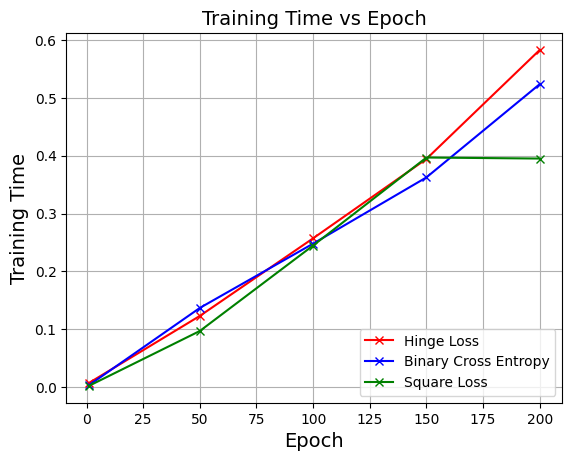

In [6]:
plt.plot(epochs, htime, color = "Red", label = "Hinge Loss", marker = "x")
plt.plot(epochs, btime, color = "Blue", label = "Binary Cross Entropy", marker = "x")
plt.plot(epochs, stime, color = "Green", label = "Square Loss", marker = "x")
plt.title('Training Time vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

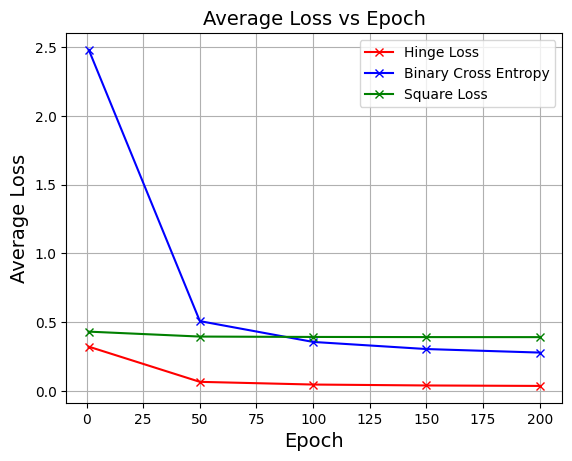

In [7]:
plt.plot(epochs, hingeloss, color = "Red", label = "Hinge Loss", marker = "x")
plt.plot(epochs, bce, color = "Blue", label = "Binary Cross Entropy", marker = "x")
plt.plot(epochs, sl, color = "Green", label = "Square Loss", marker = "x")
plt.title('Average Loss vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Average Loss', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

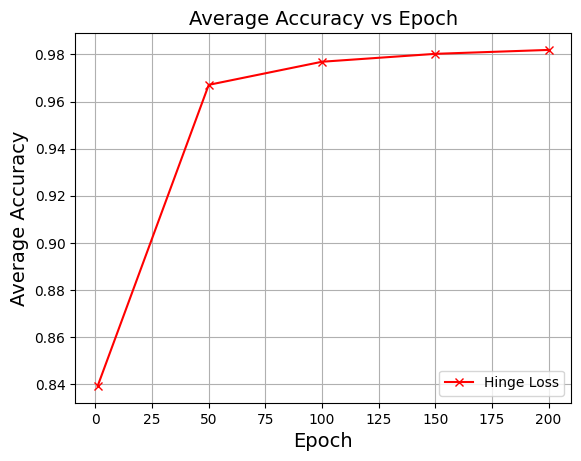

In [8]:
plt.plot(epochs, haccuracy, color = "Red", label = "Hinge Loss", marker = "x") # they all have the same accuracy
plt.title('Average Accuracy vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Average Accuracy', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [9]:
# values
print("hinge loss", hingeloss)
print("hinge accuracy", haccuracy)
print("hinge time", htime)

print("bce loss", bce)
print("bce accuracy", baccuracy)
print("bce time", btime)

print("square loss", sl)
print("square loss accuracy", saccuracy)
print("square loss time", stime)

hinge loss [0.32156862745098047, 0.06580392156862815, 0.046171568627451434, 0.03945915032679748, 0.036131127450980315]
hinge accuracy [0.83921568627451, 0.9670980392156865, 0.9769142156862796, 0.9802704248366086, 0.9819344362745183]
hinge time [0.00699925422668457, 0.12306070327758789, 0.25726985931396484, 0.3945131301879883, 0.5829901695251465]
bce loss [2.4800897540971105, 0.5075110496801949, 0.35609703344291543, 0.3043276802425442, 0.2786603895583009]
bce accuracy [0.83921568627451, 0.9670980392156865, 0.9769142156862796, 0.9802704248366086, 0.9819344362745183]
bce time [0.003100156784057617, 0.1368732452392578, 0.24805665016174316, 0.3625986576080322, 0.5238332748413086]
square loss [0.4310049019607843, 0.3951102941176478, 0.39235906862744946, 0.3913684640522844, 0.39101838235293757]
square loss accuracy [0.83921568627451, 0.9670980392156865, 0.9769142156862796, 0.9802704248366086, 0.9819344362745183]
square loss time [0.001997232437133789, 0.0969991683959961, 0.2447965145111084, 0

### Activation Function Graphs

In [10]:
tloss, tacc, ttime = activation_test(1)
rloss, racc, rtime = activation_test(2)
sloss, sacc, st = activation_test(3)

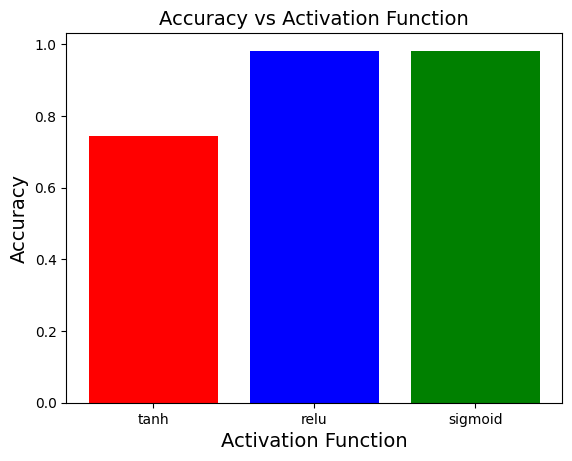

In [11]:
plt.bar(["tanh", "relu", "sigmoid"], [tacc, racc, sacc], color = ["red", "blue", "green"])
plt.title('Accuracy vs Activation Function', fontsize = 14)
plt.xlabel('Activation Function', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.show()

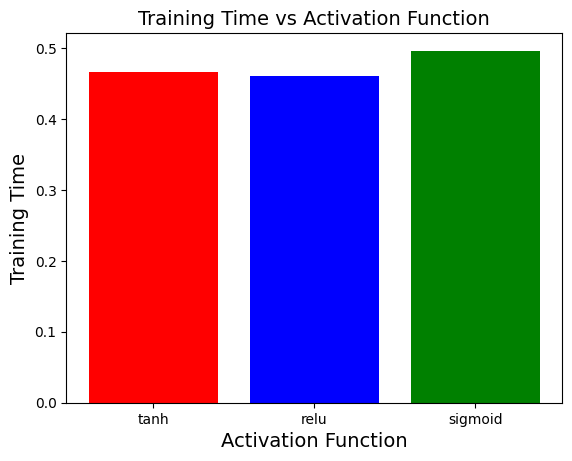

In [12]:
plt.bar(["tanh", "relu", "sigmoid"], [ttime, rtime, st], color = ["red", "blue", "green"])
plt.title('Training Time vs Activation Function', fontsize = 14)
plt.xlabel('Activation Function', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.show()

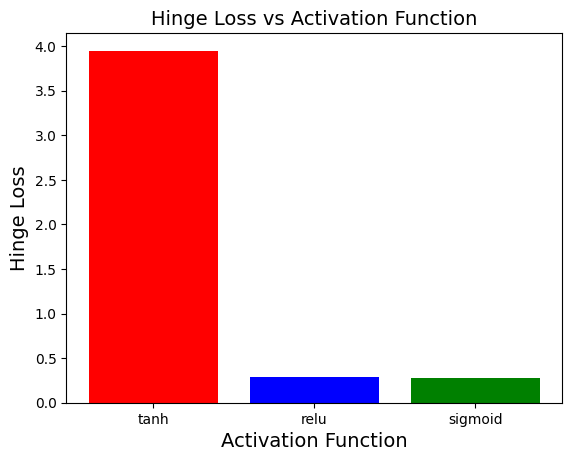

In [13]:
plt.bar(["tanh", "relu", "sigmoid"], [tloss, rloss, sloss], color = ["red", "blue", "green"])
plt.title('Hinge Loss vs Activation Function', fontsize = 14)
plt.xlabel('Activation Function', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.show()

In [14]:
# values
print("tan loss", tloss)
print("tan accuracy", tacc)
print("tan time", ttime)

print("relu loss", rloss)
print("relu accuracy", racc)
print("relu time", rtime)

print("sigmoid loss", sloss)
print("sigmoid accuracy", sacc)
print("sigmoid time", st)

tan loss 3.948134650694166
tan accuracy 0.7440422794117626
tan time 0.4656951427459717
relu loss 0.2854938685678039
relu accuracy 0.9814914215686359
relu time 0.4605989456176758
sigmoid loss 0.2786603895583009
sigmoid accuracy 0.9819344362745183
sigmoid time 0.4961884021759033


### Learning Rate Graphs

In [15]:
schloss, schacc, scht = lr_test(lr, 1)
nschloss, nschacc, nscht = lr_test(lr, 0)

c:\Year 4\F20BC\F20BC-ANN\NeuralNet.py:114: RuntimeWarning: invalid value encountered in multiply
  error = np.dot((self.layers[i].weights).T, error) * self.layers[i-1].activation_prime(self.layers[i-1].wsum)


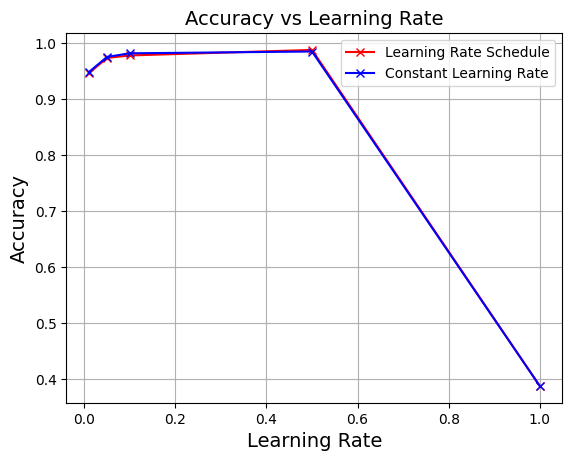

In [16]:
plt.plot(lr, schacc, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nschacc, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Accuracy vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

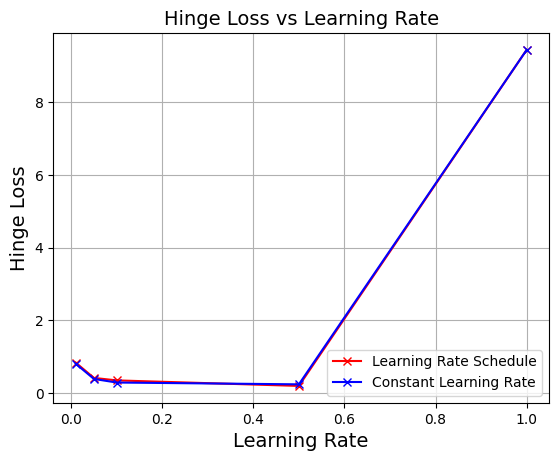

In [45]:
plt.plot(lr, schloss, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nschloss, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Hinge Loss vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

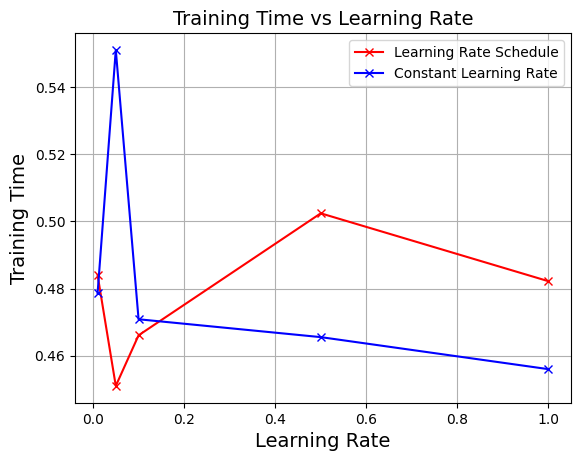

In [18]:
plt.plot(lr, scht, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nscht, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Training Time vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

In [19]:
# values
print("learing schedule loss", schloss)
print("learing schedule accuracy", schacc)
print("learing schedule time", scht)
print("constant learing loss", nschloss)
print("constant learing accuracy", nschacc)
print("constant learing time", nscht)

learing schedule loss [0.8344027578891219, 0.4125606622184585, 0.34455667677430474, 0.19227311687342066, 9.43545610184141]
learing schedule accuracy [0.9459056372549172, 0.9732536764706006, 0.9776623774509922, 0.9875349264705955, 0.3882990196078392]
learing schedule time [0.48403167724609375, 0.45093345642089844, 0.4660336971282959, 0.5024380683898926, 0.4821751117706299]
constant learing loss [0.8030235735006416, 0.3843855571997481, 0.2854938685678039, 0.2357503000624551, 9.43545610184141]
constant learing accuracy [0.9479399509804063, 0.9750802696078541, 0.9814914215686359, 0.9847162990196168, 0.3882990196078392]
constant learing time [0.47855305671691895, 0.5511932373046875, 0.4708232879638672, 0.46549367904663086, 0.4559321403503418]


### Hidden Layers Graphs

In [20]:
layerloss, layeraccuracy, layertime = hl_test(hidden_layers)

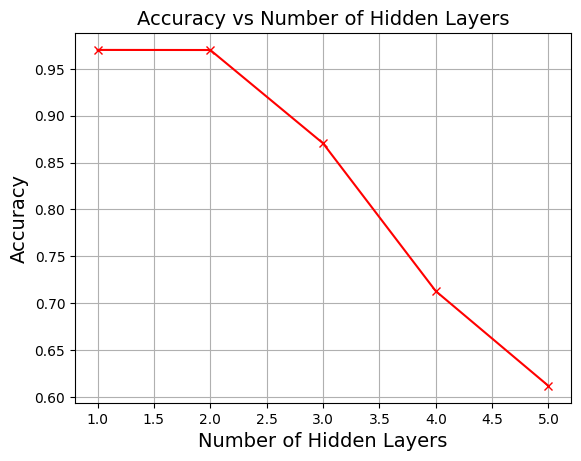

In [21]:
plt.plot(hidden_layers, layeraccuracy, color = "Red", label = "Hidden Layers", marker = "x")
plt.title('Accuracy vs Number of Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Layers', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.grid(True)
plt.show()

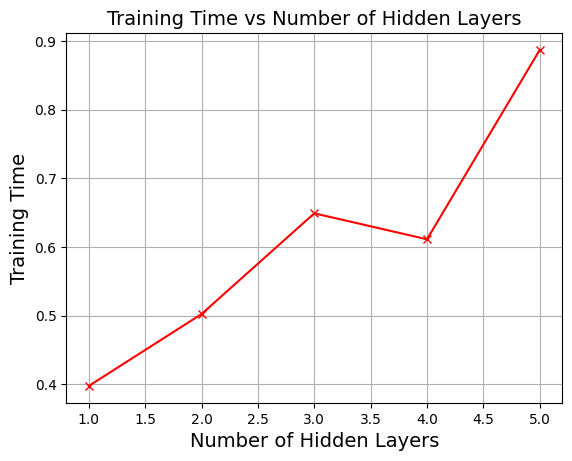

In [22]:
plt.plot(hidden_layers, layertime, color = "Red", label = "Hidden Layers", marker = "x")
plt.title('Training Time vs Number of Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Layers', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.grid(True)
plt.show()

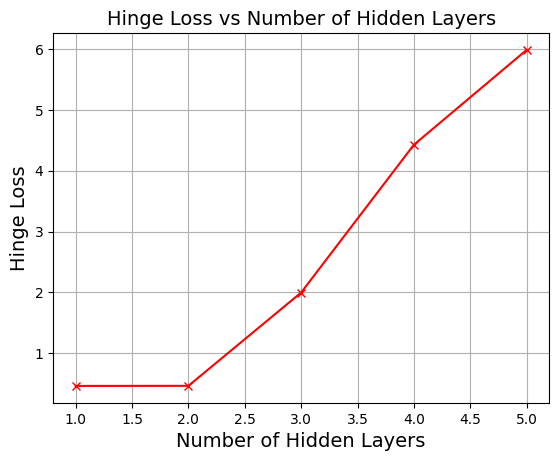

In [23]:
plt.plot(hidden_layers, layerloss, color = "Red", label = "Hidden Layers", marker = "x")
plt.title('Hinge Loss vs Number of Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Layers', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.grid(True)
plt.show()

In [24]:
# values
print("hidden layer loss", layerloss)
print("hidden layer accuracy", layeraccuracy)
print("hidden layer time", layertime)

hidden layer loss [0.4593364403927814, 0.46086759336686667, 1.9959051583601732, 4.4284346546823015, 5.988792953103548]
hidden layer accuracy [0.9702212009804037, 0.9701219362745184, 0.8706053921568698, 0.7129044117647123, 0.6117463235294154]
hidden layer time [0.3974263668060303, 0.5021209716796875, 0.648878812789917, 0.6110320091247559, 0.8869078159332275]


### Hidden Neurons Graphs

In [25]:
oneloss, oneacc, onet = hn_test(hidden_neurons, 1)
twoloss, twoacc, twot = hn_test(hidden_neurons, 2)

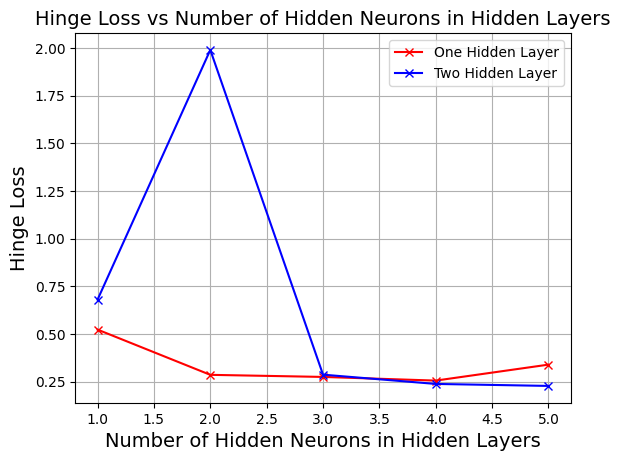

In [26]:
plt.plot(hidden_neurons, oneloss, color = "Red", label = "One Hidden Layer", marker = "x")
plt.plot(hidden_neurons, twoloss, color = "Blue", label = "Two Hidden Layer", marker = "x")
plt.title('Hinge Loss vs Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

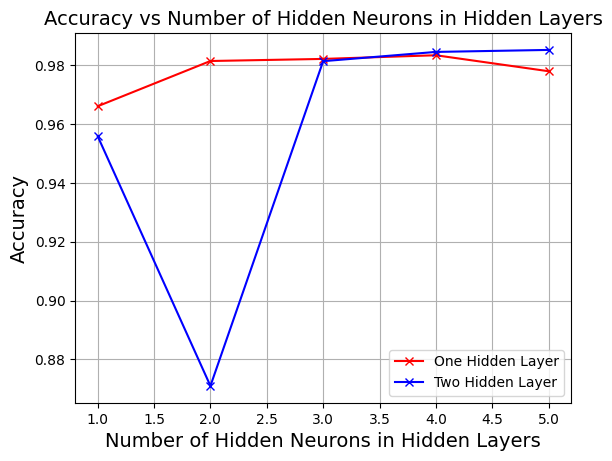

In [27]:
plt.plot(hidden_neurons, oneacc, color = "Red", label = "One Hidden Layer", marker = "x")
plt.plot(hidden_neurons, twoacc, color = "Blue", label = "Two Hidden Layer", marker = "x")
plt.title('Accuracy vs Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

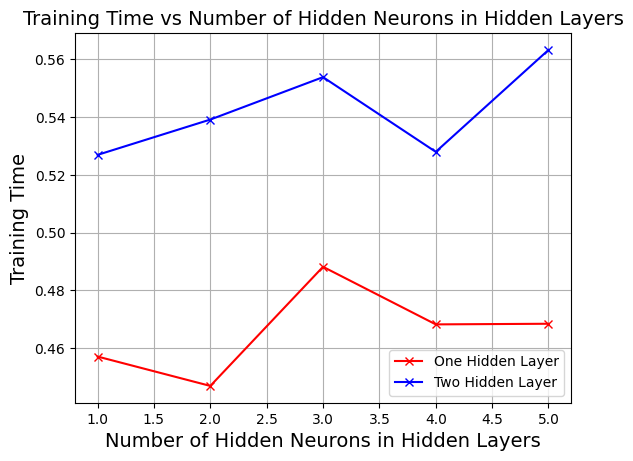

In [28]:
plt.plot(hidden_neurons, onet, color = "Red", label = "One Hidden Layer", marker = "x")
plt.plot(hidden_neurons, twot, color = "Blue", label = "Two Hidden Layer", marker = "x")
plt.title('Training Time vs Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.xlabel('Number of Hidden Neurons in Hidden Layers', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [29]:
# values
print("one hidden layer loss", oneloss)
print("one hidden layer accuracy", oneacc)
print("one hidden layer time", onet)

print("two hidden layer loss", twoloss)
print("two hidden layer accuracy", twoacc)
print("two hidden layer time", twot)

one hidden layer loss [0.5227847731669258, 0.2854938685678039, 0.27453950871676414, 0.2552866778131542, 0.3391031257525974]
one hidden layer accuracy [0.9661078431372718, 0.9814914215686359, 0.9822015931372633, 0.9834497549019687, 0.9780159313725578]
one hidden layer time [0.45705366134643555, 0.44687843322753906, 0.4881455898284912, 0.4681966304779053, 0.4684140682220459]
two hidden layer loss [0.6802194341202966, 1.990281479204043, 0.28639176691652024, 0.2378107404832765, 0.22733841027206775]
two hidden layer accuracy [0.9559013480392327, 0.8709699754902037, 0.9814332107843226, 0.9845827205882409, 0.9852616421568676]
two hidden layer time [0.5269205570220947, 0.5391535758972168, 0.5538475513458252, 0.5279698371887207, 0.5632789134979248]


### Output Nodes Graphs

In [30]:
onenloss, onenacc, onent = outputnodes(1)
twonloss, twonacc, twont = outputnodes(2)

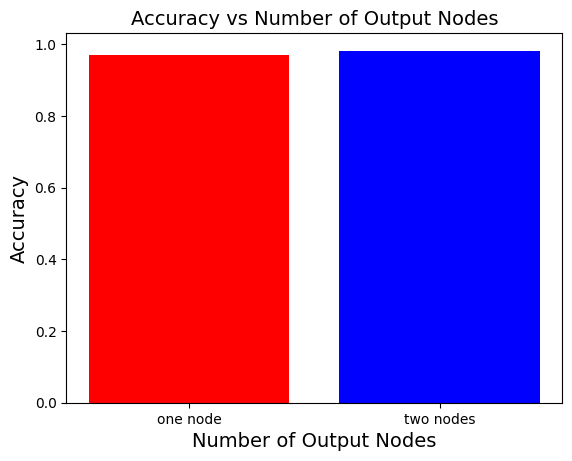

In [31]:
plt.bar(["one node", "two nodes"], [onenacc, twonacc], color = ["red", "blue"])
plt.title('Accuracy vs Number of Output Nodes', fontsize = 14)
plt.xlabel('Number of Output Nodes', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.show()

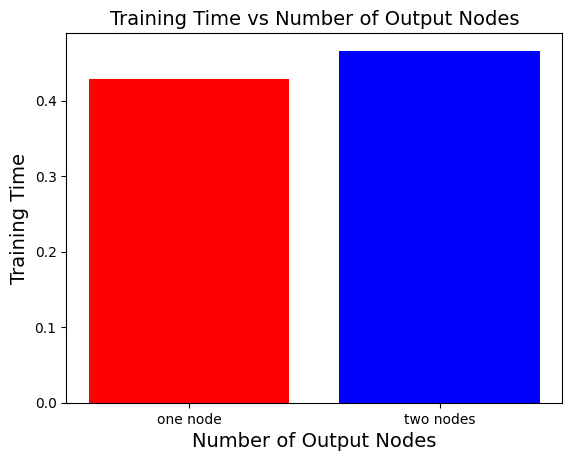

In [32]:
plt.bar(["one node", "two nodes"], [onent, twont], color = ["red", "blue"])
plt.title('Training Time vs Number of Output Nodes', fontsize = 14)
plt.xlabel('Number of Output Nodes', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.show()

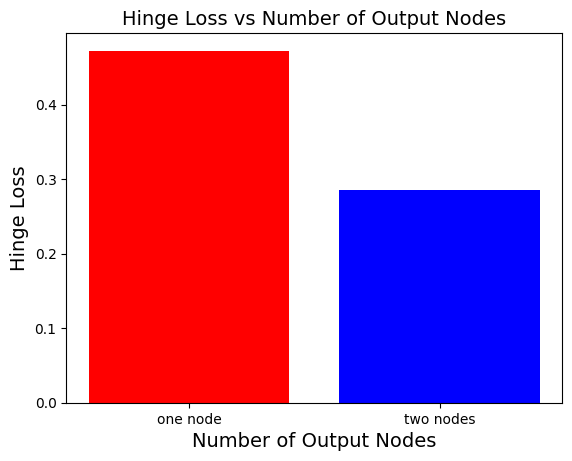

In [33]:
plt.bar(["one node", "two nodes"], [onenloss, twonloss], color = ["red", "blue"])
plt.title('Hinge Loss vs Number of Output Nodes', fontsize = 14)
plt.xlabel('Number of Output Nodes', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.show()

In [34]:
# values
print("one output node loss", onenloss)
print("one output node accuracy", onenacc)
print("one output node time", onent)

print("two output node loss", twonloss)
print("two output node accuracy", twonacc)
print("two output node time", twont)

one output node loss 0.47255917501800937
one output node accuracy 0.9693639705882474
one output node time 0.42880749702453613
two output node loss 0.2854938685678039
two output node accuracy 0.9814914215686359
two output node time 0.46601414680480957


### Binary Cross Entropy with Sigmoid vs ReLU

In [35]:
# bce with sigmoid vs relu 
bcer, baccuracyr, btimer = epoch_test(epochs, 1, 2)

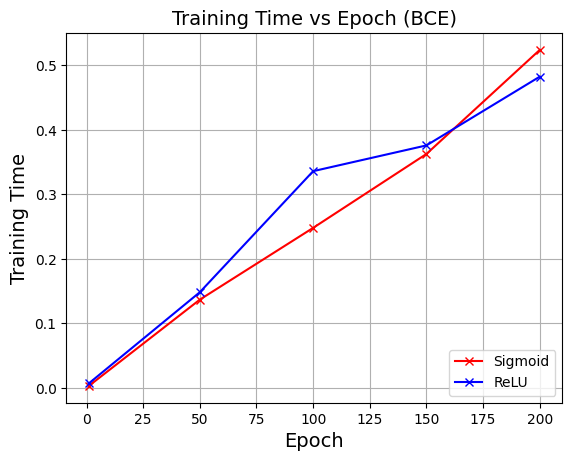

In [36]:
plt.plot(epochs, btime, color = "Red", label = "Sigmoid", marker = "x")
plt.plot(epochs, btimer, color = "Blue", label = "ReLU", marker = "x")
plt.title('Training Time vs Epoch (BCE)', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

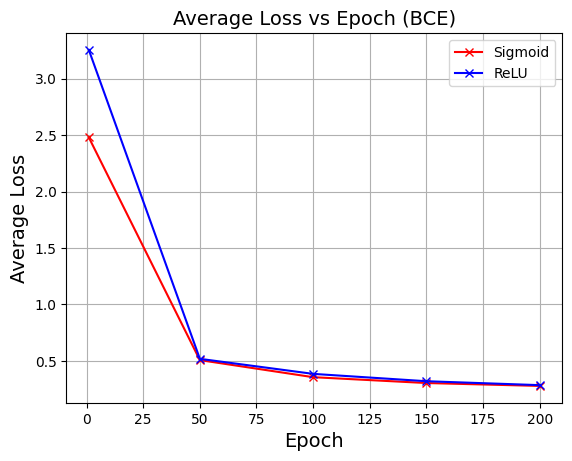

In [37]:
plt.plot(epochs, bce, color = "Red", label = "Sigmoid", marker = "x")
plt.plot(epochs, bcer, color = "Blue", label = "ReLU", marker = "x")
plt.title('Average Loss vs Epoch (BCE)', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Average Loss', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

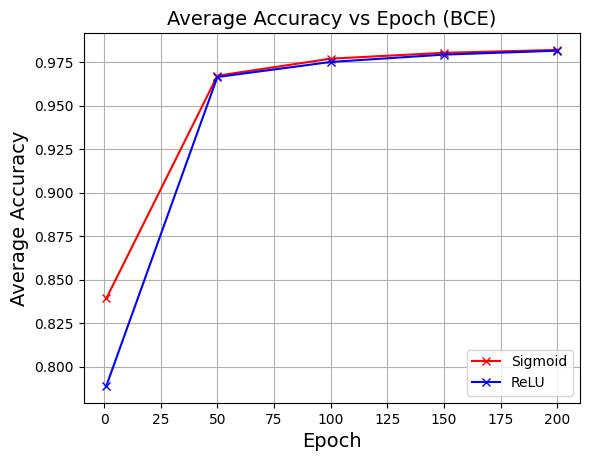

In [38]:
plt.plot(epochs, baccuracy, color = "Red", label = "Sigmoid", marker = "x")
plt.plot(epochs, baccuracyr, color = "Blue", label = "ReLU", marker = "x")
plt.title('Average Accuracy vs Epoch (BCE)', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Average Accuracy', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [39]:
# values
print("bce loss sigmoid", bce)
print("bce accuracy sigmoid", baccuracy)
print("bce time sigmoid", btime)

print("bce loss relu", bcer)
print("bce accuracy relu", baccuracyr)
print("bce time relu", btimer)

bce loss sigmoid [2.4800897540971105, 0.5075110496801949, 0.35609703344291543, 0.3043276802425442, 0.2786603895583009]
bce accuracy sigmoid [0.83921568627451, 0.9670980392156865, 0.9769142156862796, 0.9802704248366086, 0.9819344362745183]
bce time sigmoid [0.003100156784057617, 0.1368732452392578, 0.24805665016174316, 0.3625986576080322, 0.5238332748413086]
bce loss relu [3.2551178022200338, 0.5186260860761288, 0.3853590680406882, 0.32024410991382185, 0.2854938685678039]
bce accuracy relu [0.7889705882352943, 0.9663774509803923, 0.9750171568627511, 0.979238562091511, 0.9814914215686359]
bce time relu [0.0069980621337890625, 0.14837932586669922, 0.33592724800109863, 0.3758523464202881, 0.48238229751586914]


In [40]:
sgdl, sgda, sgdt = gd_test(1, 1)
bgdl, bgda, bgdt = gd_test(2, 1)
mgdl, mgda, mgdt = gd_test(3, 30)

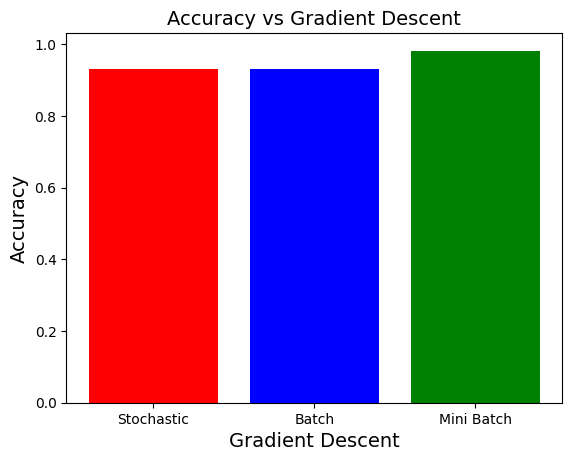

In [41]:
plt.bar(["Stochastic", "Batch", "Mini Batch"], [sgda, bgda, mgda], color = ["red", "blue", "green"])
plt.title('Accuracy vs Gradient Descent', fontsize = 14)
plt.xlabel('Gradient Descent', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.show()

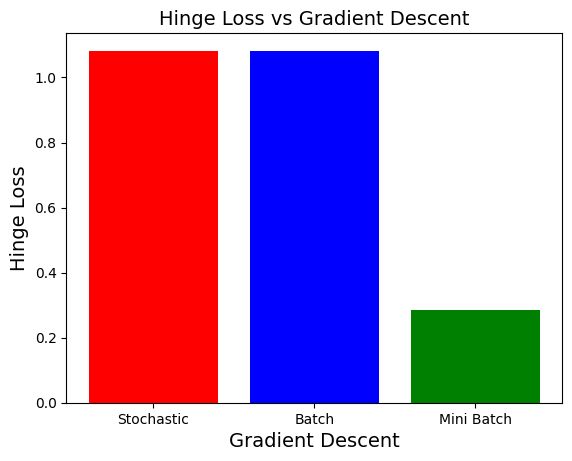

In [42]:
plt.bar(["Stochastic", "Batch", "Mini Batch"], [sgdl, bgdl, mgdl], color = ["red", "blue", "green"])
plt.title('Hinge Loss vs Gradient Descent', fontsize = 14)
plt.xlabel('Gradient Descent', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.show()

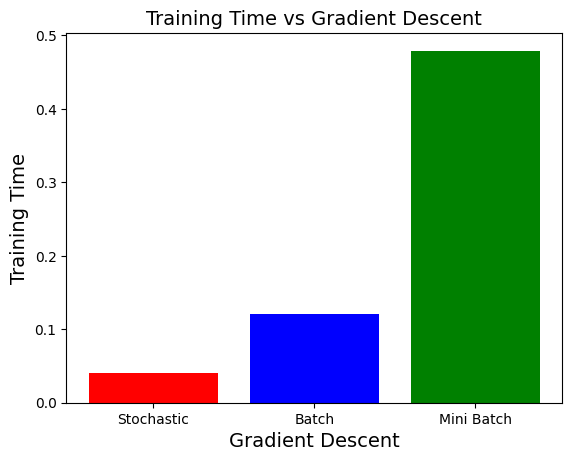

In [43]:
plt.bar(["Stochastic", "Batch", "Mini Batch"], [sgdt, bgdt, mgdt], color = ["red", "blue", "green"])
plt.title('Training Time vs Gradient Descent', fontsize = 14)
plt.xlabel('Gradient Descent', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.show()

In [44]:
# values
print("stochastic loss", sgdl)
print("stochastic accuracy", sgda)
print("stochastic time", sgdt)

print("batch loss", bgdl)
print("batch accuracy", bgda)
print("batch time", bgdt)

print("mini batch loss", mgdl)
print("mini batch accuracy", mgda)
print("mini batch time", mgdt)

stochastic loss 1.0822945672427122
stochastic accuracy 0.929834801762114
stochastic time 0.040008544921875
batch loss 1.082294567242712
batch accuracy 0.929834801762114
batch time 0.12019801139831543
mini batch loss 0.2854938685678039
mini batch accuracy 0.9814914215686359
mini batch time 0.4791865348815918
